In [15]:
from Data_polisher import DataPolish
import pandas as pd
from catboost import CatBoostClassifier
from ModelTrainer import ModelTrainer
from sklearn.model_selection import train_test_split

In [2]:
train = pd.read_csv('train_final_processed.csv')
test = pd.read_csv('test_final_processed.csv')

In [3]:
y = train['target']   
X_train = train.drop(columns=['target'])  
X_test = test.copy()                    

polisher = DataPolish(
    max_na_ratio=0.6,
    corr_threshold=0.95,
    handle_outliers=True,
    outlier_method='clip',
    log_transform_skew=2.0,
    scale_numeric=False,
    verbose=True
)

X_train_clean = polisher.fit_transform(X_train) 
X_test_clean = polisher.transform(X_test)        

print(f"Трейн: {X_train_clean.shape}, Тест: {X_test_clean.shape}")
print("Удалено колонок:", len(polisher.get_dropped_columns()))

cat_features = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()

Удалено колонок: 28
Осталось 542 из 570

Удалено 115 коррелирующих признаков(>0.95)
Трейн: (307511, 427), Тест: (48744, 427)
Удалено колонок: 143


In [4]:
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=7,
    auto_class_weights='SqrtBalanced',
    random_state=42,
    verbose=100,
    early_stopping_rounds=150,
    eval_metric='AUC'
)

In [16]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train_clean, y, test_size=0.2, random_state=42, stratify=y)

trainer = ModelTrainer(model, experiment_name="baseline_clean_data")

In [23]:
trainer.fit(X_tr, y_tr, X_val=X_val, y_val=y_val, cat_features=cat_features)

Модель: CatBoostClassifier
0:	test: 0.6956615	best: 0.6956615 (0)	total: 1.08s	remaining: 17m 55s
100:	test: 0.7566125	best: 0.7566125 (100)	total: 1m 29s	remaining: 13m 20s
200:	test: 0.7658209	best: 0.7658209 (200)	total: 2m 50s	remaining: 11m 18s
300:	test: 0.7702684	best: 0.7702684 (300)	total: 4m 6s	remaining: 9m 31s
400:	test: 0.7729467	best: 0.7729467 (400)	total: 5m 48s	remaining: 8m 41s
500:	test: 0.7753149	best: 0.7753149 (500)	total: 7m 31s	remaining: 7m 29s
600:	test: 0.7766128	best: 0.7766128 (600)	total: 9m 3s	remaining: 6m
700:	test: 0.7778164	best: 0.7778164 (700)	total: 10m 35s	remaining: 4m 31s
800:	test: 0.7784566	best: 0.7784566 (800)	total: 12m 12s	remaining: 3m 1s
900:	test: 0.7787975	best: 0.7787975 (900)	total: 13m 47s	remaining: 1m 30s
999:	test: 0.7791126	best: 0.7792020 (976)	total: 15m 36s	remaining: 0us

bestTest = 0.7792020389
bestIteration = 976

Shrink model to first 977 iterations.
РЕЗУЛЬТАТЫ — baseline_clean_data
Val ROC-AUC       : 0.77920
Val PR-AUC 

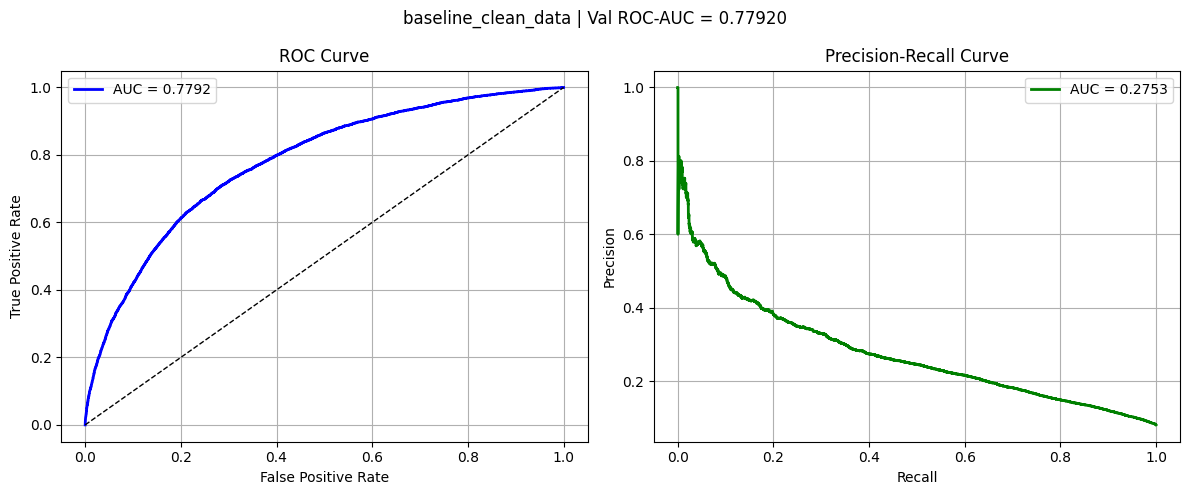

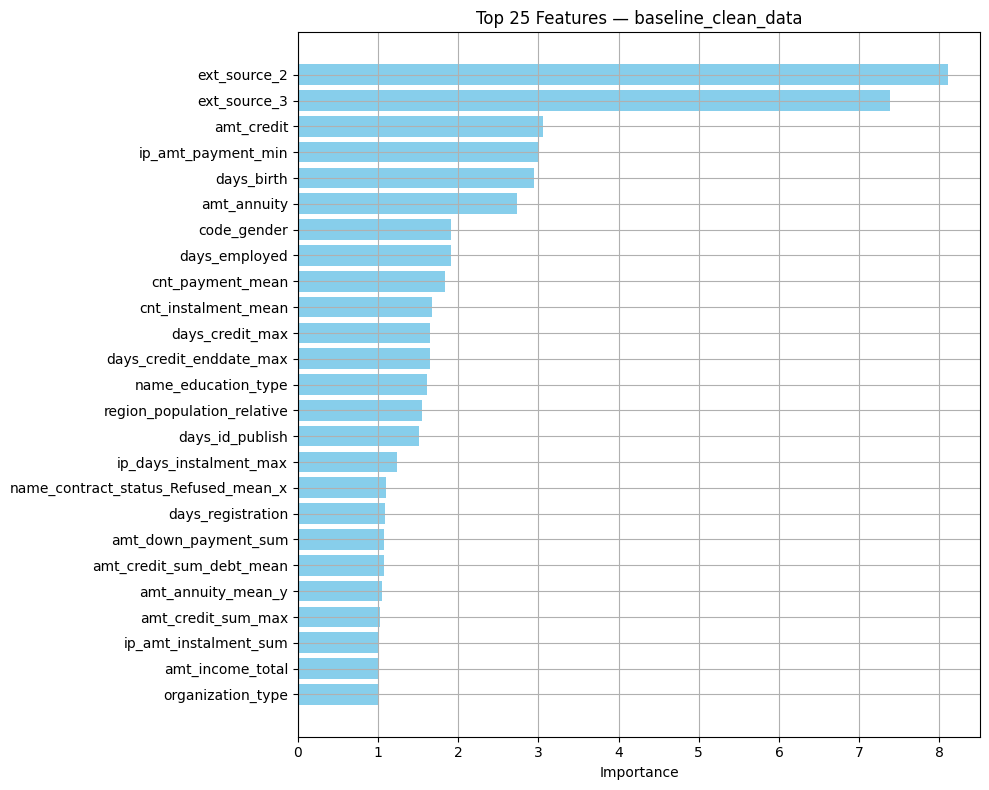

Сабмит сохранён: results/submission_baseline_clean_data.csv
   Val ROC-AUC: 0.77920 | Порог: 0.2249


In [25]:

val_proba = trainer.model.predict_proba(X_val)[:, 1]

trainer.plot_curves(y_val=y_val, val_proba=val_proba)

trainer.plot_importance(top_n=25)

test_proba, _ = trainer.predict_test(X_test_clean)
trainer.make_submission(test['sk_id_curr'], test_proba)